# Phase 4B — Adaptive ML Signal Models (F7)

**Purpose:** This notebook is *evidentiary*, not exploratory. It shows what F7 — the EURAFRIC
functional diagram's "Adaptive ML Models (RF/XGBoost/LSTM), HMM regime-conditional return
prediction, signals for portfolio optimization" — actually does on live data, and reports the
honest result against the Phase 4 hurdle every Phase 4B strategy must beat net of costs,
out-of-sample.

**F7 is not Phase 4 (F4).** F4 — already built, `notebooks/phase4_regime_covariance.ipynb` —
detects a market regime and hard-switches between two existing Markowitz optimizers. It never
predicts a return. F7 is the missing piece: a supervised model that learns to forecast each
asset's next-period return, conditioned on the HMM regime posterior as one input feature, and
feeds that prediction as `mu` into the *same* Sharpe-maximization objective every prior Phase 4
covariance rung already reused — zero new optimizer code.

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | Predicted `mu` replaces the noisy sample mean already fed into `MaxSharpe`'s objective — does a learned estimate actually beat the naive one net of costs? |
| **P2** | The pooled model conditions on regime and rolling per-asset features rather than assuming a static return distribution — §3 checks whether the regime feature is actually used, not just present |
| **P3** | The pooled cross-sectional panel (asset identity as a feature, not per-asset models) lets every asset's rows inform the same fit — the practical answer to `full_2021`'s thin ~1,255-row history |
| **P4** | Every strategy compared here runs through the *same* leakage-free engine Phase 2 built; `tests/test_phase4b_integration.py` proves **label construction** (not just feature slicing) doesn't leak, end-to-end, for the real strategies — this notebook does not re-litigate that proof, it reports results from it |

**No-lookahead guarantee — proven elsewhere, not here:** `tests/test_phase4b_integration.py`
already proves `RandomForestSignalStrategy`/`XGBoostSignalStrategy` cannot see a future realized
return, using the real strategies (not a toy probe) — the labels-specific version of the proof
`test_phase4_integration.py` already ran for Phase 4's features. This notebook trusts that proof
and focuses on what the models *found*, not on re-deriving that they're honest.

**Data caveats carried forward from Phase 1–4 (see `CLAUDE.md` §8.4 for the full list):**
- `full_2021` (9 assets) starts mid-2021 (BVC free-source rolling window); `etf_2017` (5 ETFs)
  covers 2017→today.
- `EEM` is stationarity-AMBIGUOUS — unchanged risk, inherited from Phase 1.
- BVC returns are MAD-denominated, ETFs USD — an unhedged USD/MAD exposure is embedded and not
  "fixed" here (out of scope).
- **LSTM (the third F7 model family) was built and passed its own isolated 10-test suite, then
  dropped from this comparison** after `torch` and `xgboost` loaded together in the same process
  caused a hard segfault — a native/OpenMP library conflict on this development machine, not a
  defect in either library. Deferred to a run on more capable/isolated hardware, not abandoned;
  no LSTM code remains on this branch. See `CLAUDE.md`'s Phase 4B notes for the full story.

> ## ⚠️ Numbers below are PRE-CORRECTION (superseded 2026-07-25)
>
> Two data corrections landed after this notebook was executed. **Every Sharpe figure below is
> kept as the honest record of what this phase found at the time — none of them is the current
> number.**
>
> **1. BVC dividend bias.** The pipeline mixed two return definitions: ETFs arrived
> dividend-adjusted (`yfinance auto_adjust=True`, total return) while BVC arrived price-only
> (`BVCscrap feature="Value"`), discarding 3.0–4.3%/yr of real dividends. It did not cancel across
> strategies — `equal_weight` is forced to hold the understated assets while the optimizers can
> underweight them, so it **inflated every optimizer's measured edge**. Fixed in `src/dividends.py`
> + `clean.compute_log_returns(prices, dividends=...)`, which applies each payment on its ex-date.
>
> **2. Deep ETF window.** `etf_2017` now starts **2004-11-18** (GLD's inception), not 2017-01-01.
> The old start was a project decision, not a data limit. This cut bootstrap CI width by 38% and
> brought the 2008 crisis into the sample.
>
> | | Pre-correction (below) | Current |
> |---|---:|---:|
> | `etf_2017` hurdle | `max_sharpe` 0.936 | **`min_variance_lw` 0.9525** |
> | `full_2021` hurdle | `equal_weight` 0.975 | **`max_sharpe` 1.1644** |
> | `regime_conditional` (`full_2021`) | 1.122 | **1.236** |
> | Headline lift vs. classical | +14.3% | **+6.5%** |
>
> **The conclusions survive; the magnitudes shrank.** `regime_conditional` still beats the hurdle
> on `full_2021`. But two *claims* in this notebook are retracted outright — see the inline
> **[RETRACTED]** / **[SUPERSEDED]** notes below.
>
> Full analysis: [`docs/DIVIDEND_BIAS.md`](../docs/DIVIDEND_BIAS.md) ·
> [`docs/ETF_DEEP_HISTORY_EXPERIMENT.md`](../docs/ETF_DEEP_HISTORY_EXPERIMENT.md)


## 1. Setup — universes, Phase 3 features, and the Phase 4 hurdle (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
SRC = (NB_CWD.parent / "src") if (NB_CWD.parent / "src").exists() else (NB_CWD / "src")
sys.path.insert(0, str(SRC))

from backtest import build_cost_vector, run_backtest
from metrics import annualized_sharpe, max_drawdown, summarize
from run_phase4b import PHASE4B_STRATEGY_NAMES, ROOT, build_strategies
from run_phase4 import load_features, load_universe
from utils import load_params

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

P = load_params()
BP = P["backtest"]
SP = P["ml_signals"]

UNIVERSES = {name: load_universe(path) for name, path in BP["universes"].items()}
FEATURES = {name: load_features(P["ml_features"]["outputs"][name]) for name in BP["universes"]}
HURDLE = json.loads((ROOT / "data" / "gold" / "phase4_results.json").read_text())

for name, df in UNIVERSES.items():
    print(f"{name}: {df.shape[0]} days x {df.shape[1]} assets   "
          f"{df.index.min().date()} -> {df.index.max().date()}   "
          f"Phase 4 hurdle: {HURDLE[name]['strategy']} @ {HURDLE[name]['sharpe_net']:.4f}")

/Users/apple/Projects/Portfolio_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


etf_2017: 2489 days x 5 assets   2017-01-04 -> 2026-07-20   Phase 4 hurdle: max_sharpe @ 0.9362
full_2021: 1317 days x 9 assets   2021-07-02 -> 2026-07-20   Phase 4 hurdle: regime_conditional @ 1.1215


## 2. Run the full comparison — 7 existing strategies + 2 new F7 strategies (P1–P4)

One pass, both universes: the 4 Phase 2 baselines and 3 Phase 4 strategies (`EqualWeight`,
`MinVariance`, `MinVarianceLW`, `MaxSharpe`, `MinVarianceEWMA`, `DCCGarchStrategy`,
`RegimeConditionalStrategy`) alongside the 2 new F7 strategies (`RandomForestSignalStrategy`,
`XGBoostSignalStrategy`) — the exact same `build_strategies()` `src/run_phase4b.py` uses, so this
notebook's numbers are the live, reproducible ones, not a hand-copied table. The DSR
`trial_sharpes` pool is honest across all 9 (the N-honesty rule from `run_phase4b.py`'s
docstring).

**Runtime note:** dominated by `DCCGarchStrategy`'s per-asset GARCH refits and the two pooled-panel
model refits at every rebalance — expect several minutes, most of it in this cell.

In [2]:
STRATEGIES_BY_UNIVERSE = {name: build_strategies(P) for name in UNIVERSES}

RESULTS = {}
for uni_name, returns in UNIVERSES.items():
    costs = build_cost_vector(
        returns.columns,
        etf_cost_bps=BP["costs_bps"]["etf"],
        bvc_cost_bps=BP["costs_bps"]["bvc"],
    )
    RESULTS[uni_name] = [
        run_backtest(
            returns, s,
            rebalance_freq=BP["rebalance_freq"],
            min_train_days=BP["min_train_days"],
            cost_bps=costs,
            extras={"features": FEATURES[uni_name]},
            universe_name=uni_name,
            max_weight=BP["max_weight"],
        )
        for s in STRATEGIES_BY_UNIVERSE[uni_name]
    ]
    print(f"{uni_name}: {len(RESULTS[uni_name])} strategies backtested "
          f"({', '.join(r.strategy_name for r in RESULTS[uni_name])}).")

2026-07-21 18:52:31,372 | INFO | backtest | Backtest equal_weight/etf_2017: 103 rebalances, OOS 2018-01-01 → 2026-07-20 (2231 days), avg turnover 0.036


2026-07-21 18:52:31,713 | INFO | backtest | Backtest min_variance/etf_2017: 103 rebalances, OOS 2018-01-01 → 2026-07-20 (2231 days), avg turnover 0.042


2026-07-21 18:52:32,403 | INFO | backtest | Backtest min_variance_lw/etf_2017: 103 rebalances, OOS 2018-01-01 → 2026-07-20 (2231 days), avg turnover 0.042


2026-07-21 18:52:32,616 | INFO | backtest | Backtest max_sharpe/etf_2017: 103 rebalances, OOS 2018-01-01 → 2026-07-20 (2231 days), avg turnover 0.048


2026-07-21 18:52:33,513 | INFO | backtest | Backtest min_variance_ewma/etf_2017: 103 rebalances, OOS 2018-01-01 → 2026-07-20 (2231 days), avg turnover 0.086


...

2026-07-21 19:04:52,721 | WARNING | regime | regime: only 198 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-21 19:04:52,913 | WARNING | regime | regime: only 219 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-21 19:04:53,102 | WARNING | regime | regime: only 242 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-21 19:05:12,583 | INFO | backtest | Backtest xgb_signal/full_2021: 49 rebalances, OOS 2022-07-01 → 2026-07-20 (1057 days), avg turnover 1.076


full_2021: 9 strategies backtested (equal_weight, min_variance, min_variance_lw, max_sharpe, min_variance_ewma, dcc_garch, regime_conditional, rf_signal, xgb_signal).


## 3. Does the model actually use the regime feature? (P2)

The open question flagged in `CLAUDE.md`'s Phase 4B notes: is `REGIME_BULL_PROB` pulling its
weight in the pooled model, or is "regime-conditional" a claim the model ignores in practice?
Fitted directly here (mirroring what `ml_signals.fit_predict_expected_returns` does internally)
so `feature_importances_` can be inspected — the strategies themselves don't expose the fitted
model, by design (`Strategy.fit()`'s contract returns weights only).

In [3]:
from ml_signals import (
    attach_regime_feature,
    build_asset_features,
    build_supervised_dataset,
    melt_to_panel,
)

FEATURE_IMPORTANCE = {}
for uni_name, returns in UNIVERSES.items():
    wide = build_asset_features(
        returns,
        short_window=SP["short_window"],
        long_window=SP["long_window"],
        momentum_windows=SP["momentum_windows"],
    )
    panel = melt_to_panel(wide, list(returns.columns))
    panel = attach_regime_feature(
        panel, FEATURES[uni_name],
        n_states=P["regime"]["n_states"],
        n_restarts=P["regime"]["n_restarts"],
        random_state_base=P["regime"]["random_state_base"],
        covariance_type=P["regime"]["covariance_type"],
        min_regime_train_days=P["regime"]["min_regime_train_days"],
    )
    X, y, _ = build_supervised_dataset(panel, returns)

    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor

    rf = RandomForestRegressor(**SP["random_forest"]).fit(X.to_numpy(), y.to_numpy())
    xgb = XGBRegressor(**SP["xgboost"]).fit(X.to_numpy(), y.to_numpy())

    imp = pd.DataFrame({
        "rf_importance": rf.feature_importances_,
        "xgb_importance": xgb.feature_importances_,
    }, index=X.columns).sort_values("rf_importance", ascending=False)
    FEATURE_IMPORTANCE[uni_name] = imp

    regime_rank_rf = list(imp.index).index("REGIME_BULL_PROB") + 1
    regime_rank_xgb = list(imp["xgb_importance"].sort_values(ascending=False).index).index("REGIME_BULL_PROB") + 1
    n_features = len(imp)
    print(f"=== {uni_name} ({n_features} features, {len(X)} pooled training rows) ===")
    print(f"  REGIME_BULL_PROB rank: RF {regime_rank_rf}/{n_features}, XGB {regime_rank_xgb}/{n_features}")
    print(imp.head(8))
    print()

=== etf_2017 (7 features, 12130 pooled training rows) ===
  REGIME_BULL_PROB rank: RF 7/7, XGB 5/7
                  rf_importance  xgb_importance
PRICE_REL_MA_63D         0.4524          0.1130
RET_21D                  0.2310          0.1530
RET_5D                   0.1318          0.1398
RET_63D                  0.1013          0.1740
VOL_21D                  0.0464          0.1137
VOL_63D                  0.0324          0.1867
REGIME_BULL_PROB         0.0048          0.1198



=== full_2021 (7 features, 11286 pooled training rows) ===
  REGIME_BULL_PROB rank: RF 7/7, XGB 2/7
                  rf_importance  xgb_importance
PRICE_REL_MA_63D         0.3632          0.2018
RET_5D                   0.1828          0.1333
RET_21D                  0.1736          0.1333
RET_63D                  0.1241          0.1378
VOL_21D                  0.0657          0.1207
VOL_63D                  0.0598          0.1265
REGIME_BULL_PROB         0.0307          0.1467



**Reading the ranks above:** if `REGIME_BULL_PROB` sits near the top, the "regime-conditional"
claim is earning its name. If it sits near the bottom, the pooled model is effectively ignoring
regime and leaning entirely on per-asset trailing return/volatility/price-relative-to-MA
features — worth knowing before writing "regime-conditional" into any deliverable as a claimed
advantage over a model that simply omitted the feature.

## 4. `rf_signal` vs `xgb_signal` — the turnover red flag (P1, P4)

`CLAUDE.md`'s Phase 4B result flagged `xgb_signal`'s very high turnover on `full_2021` (>1.0,
essentially a full portfolio turnover every rebalance) as the standout finding — a possible sign
the predicted-return signal is too noisy/unstable across rebalances to trust net of cost. Checked
directly here against both universes and both new strategies.

In [4]:
rows = []
for uni_name, results in RESULTS.items():
    for r in results:
        if r.strategy_name in PHASE4B_STRATEGY_NAMES:
            rows.append({
                "universe": uni_name,
                "strategy": r.strategy_name,
                "avg_turnover": float(r.turnover.mean()),
                "max_turnover": float(r.turnover.max()),
                "gross_sharpe": annualized_sharpe(r.gross_returns),
                "net_sharpe": annualized_sharpe(r.net_returns),
                "cost_drag": float((r.gross_returns - r.net_returns).sum()),
            })
turnover_table = pd.DataFrame(rows).set_index(["universe", "strategy"])
turnover_table

avg_turnover  max_turnover  gross_sharpe  net_sharpe  \
universe  strategy                                                           
etf_2017  rf_signal         0.2320        1.0000        0.7480      0.7270   
          xgb_signal        0.3556        1.0000        0.7784      0.7473   
full_2021 rf_signal         0.8853        1.5826        1.2398      1.0617   
          xgb_signal        1.0757        1.9522        0.9485      0.7431   

                      cost_drag  
universe  strategy               
etf_2017  rf_signal      0.0239  
          xgb_signal     0.0366  
full_2021 rf_signal      0.0857  
          xgb_signal     0.0982

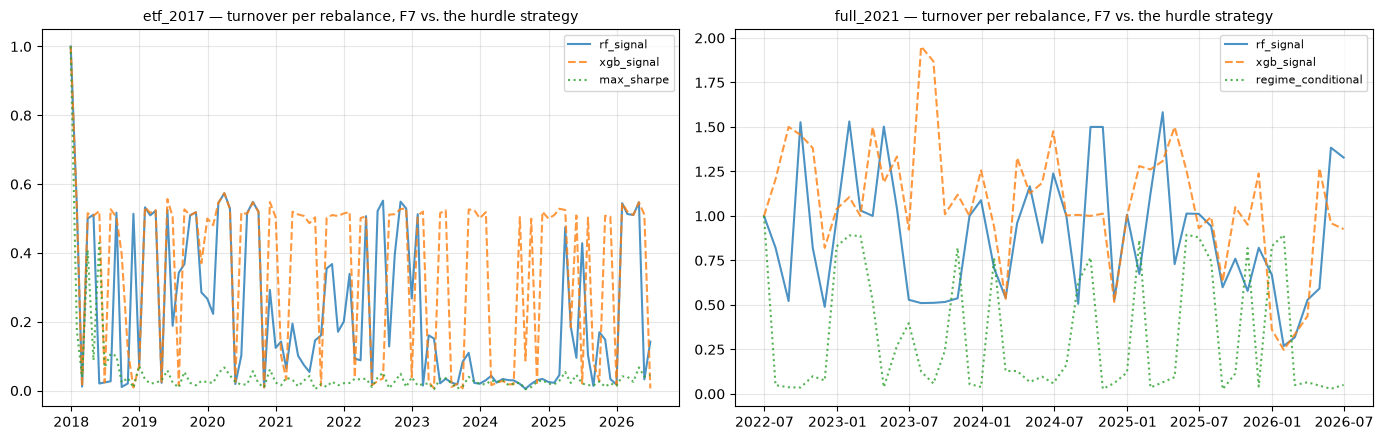

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, uni_name in zip(axes, UNIVERSES):
    by_name = {r.strategy_name: r for r in RESULTS[uni_name]}
    for name, style in [("rf_signal", "-"), ("xgb_signal", "--"), (HURDLE[uni_name]["strategy"], ":")]:
        r = by_name[name]
        ax.plot(r.turnover.index, r.turnover.values, style, label=name, alpha=0.8)
    ax.set_title(f"{uni_name} — turnover per rebalance, F7 vs. the hurdle strategy", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Full scoreboard — every Phase 4B strategy vs. the Phase 4 hurdle (P1, P4)

Same `metrics.summarize()` panel Phase 2/4 used, now over all 9 strategies with a shared DSR
trial pool per universe (the N-honesty rule from `run_phase4b.py`'s docstring) — the exact
numbers `data/gold/phase4b_results.json` was built from.

In [6]:
panels = []
for uni_name, results in RESULTS.items():
    trial_sharpes = [
        float(r.net_returns.mean() / r.net_returns.std()) if r.net_returns.std() > 0 else 0.0
        for r in results
    ]
    ew_net = next(r for r in results if r.strategy_name == "equal_weight").net_returns
    for r in results:
        panel = summarize(
            r.net_returns, r.gross_returns, r.turnover,
            benchmark_net=ew_net if r.strategy_name != "equal_weight" else None,
            trial_sharpes=trial_sharpes, risk_free_annual=BP["risk_free_annual"],
        )
        panel["universe"], panel["strategy"] = uni_name, r.strategy_name
        panel["is_phase4b"] = r.strategy_name in PHASE4B_STRATEGY_NAMES
        panels.append(panel)

metrics_table = pd.DataFrame(panels).set_index(["universe", "strategy"])
metrics_table[["ann_return_net", "sharpe_net", "max_drawdown_net", "avg_turnover", "dsr_net", "n_trials", "is_phase4b"]]

ann_return_net  sharpe_net  max_drawdown_net  \
universe  strategy                                                           
etf_2017  equal_weight                0.1046      0.8332           -0.2656   
          min_variance                0.0924      0.8263           -0.2527   
          min_variance_lw             0.0923      0.8248           -0.2527   
          max_sharpe                  0.1126      0.9362           -0.2562   
          min_variance_ewma           0.0944      0.8490           -0.2527   
          dcc_garch                   0.0941      0.8512           -0.2604   
          regime_conditional          0.1015      0.8944           -0.2640   
          rf_signal                   0.0882      0.7270           -0.2327   
          xgb_signal                  0.0936      0.7473           -0.2869   
full_2021 equal_weight                0.0962      0.9750           -0.1398   
          min_variance                0.0822      0.9008           -0.1370   
          min_variance_lw             0.0824      0.9036           -0.1363   
          max_sharpe                  0.1101      0.9634           -0.1532   
          min_variance_ewma           0.0931      1.0406           -0.1401   
          dcc_garch                   0.0912      1.0455           -0.1367   
          regime_conditional          0.1112      1.1215           -0.1496   
          rf_signal                   0.1230      1.0617           -0.1480   
          xgb_signal                  0.0821      0.7431           -0.1553   

                              avg_turnover  dsr_net  n_trials  is_phase4b  
universe  strategy                                                         
etf_2017  equal_weight              0.0360   0.9846    9.0000       False  
          min_variance              0.0424   0.9837    9.0000       False  
          min_variance_lw           0.0424   0.9836    9.0000       False  
          max_sharpe                0.0485   0.9933    9.0000       False  
          min_variance_ewma         0.0861   0.9862    9.0000       False  
          dcc_garch                 0.1963   0.9865    9.0000       False  
          regime_conditional        0.1127   0.9902    9.0000       False  
          rf_signal                 0.2320   0.9673    9.0000        True  
          xgb_signal                0.3556   0.9711    9.0000        True  
full_2021 equal_weight              0.0534   0.9481    9.0000       False  
          min_variance              0.0745   0.9297    9.0000       False  
          min_variance_lw           0.0714   0.9304    9.0000       False  
          max_sharpe                0.1858   0.9452    9.0000       False  
          min_variance_ewma         0.1775   0.9611    9.0000       False  
          dcc_garch                 0.3527   0.9631    9.0000       False  
          regime_conditional        0.3269   0.9722    9.0000       False  
          rf_signal                 0.8853   0.9645    9.0000        True  
          xgb_signal                1.0757   0.8764    9.0000        True

In [7]:
PHASE4B_RESULTS = json.loads((ROOT / "data" / "gold" / "phase4b_results.json").read_text())
for uni_name, entry in PHASE4B_RESULTS.items():
    verdict = "BEATS" if entry["beats_phase4_hurdle"] else "does not beat"
    print(f"{uni_name}: best is {entry['strategy']} (net Sharpe {entry['sharpe_net']:.4f}) "
          f"-- {verdict} the Phase 4 hurdle ({HURDLE[uni_name]['strategy']} @ {HURDLE[uni_name]['sharpe_net']:.4f})")
    for name in ("rf_signal", "xgb_signal"):
        r = next(res for res in RESULTS[uni_name] if res.strategy_name == name)
        print(f"    {name}: net Sharpe {annualized_sharpe(r.net_returns):.4f}, "
              f"avg turnover {float(r.turnover.mean()):.3f}")

etf_2017: best is max_sharpe (net Sharpe 0.9362) -- does not beat the Phase 4 hurdle (max_sharpe @ 0.9362)
    rf_signal: net Sharpe 0.7270, avg turnover 0.232
    xgb_signal: net Sharpe 0.7473, avg turnover 0.356
full_2021: best is regime_conditional (net Sharpe 1.1215) -- does not beat the Phase 4 hurdle (regime_conditional @ 1.1215)
    rf_signal: net Sharpe 1.0617, avg turnover 0.885
    xgb_signal: net Sharpe 0.7431, avg turnover 1.076


## 6. Why doesn't F7 beat the hurdle? (P1, P2, P4)

The honest negative result from §5 deserves investigation, not a shrug. Same diagnostic used in
`phase4_regime_covariance.ipynb` §7 for `etf_2017`'s negative result: is it cost drag (the signal
is directionally fine but too expensive to act on) or is the gross signal itself just not
informative enough?

In [8]:
for uni_name in UNIVERSES:
    best_baseline = next(r for r in RESULTS[uni_name] if r.strategy_name == HURDLE[uni_name]["strategy"])
    print(f"=== {uni_name} ===")
    print(f"  Phase 4 hurdle ({HURDLE[uni_name]['strategy']}) gross Sharpe: "
          f"{annualized_sharpe(best_baseline.gross_returns):.3f}, net: {annualized_sharpe(best_baseline.net_returns):.3f}")
    for name in ("rf_signal", "xgb_signal"):
        r = next(res for res in RESULTS[uni_name] if res.strategy_name == name)
        gross = annualized_sharpe(r.gross_returns)
        net = annualized_sharpe(r.net_returns)
        gap = gross - net
        print(f"  {name}: gross Sharpe {gross:.3f}, net {net:.3f} (cost gap {gap:.3f}), "
              f"avg turnover {float(r.turnover.mean()):.3f}")
    print()

=== etf_2017 ===
  Phase 4 hurdle (max_sharpe) gross Sharpe: 0.941, net: 0.936
  rf_signal: gross Sharpe 0.748, net 0.727 (cost gap 0.021), avg turnover 0.232
  xgb_signal: gross Sharpe 0.778, net 0.747 (cost gap 0.031), avg turnover 0.356

=== full_2021 ===
  Phase 4 hurdle (regime_conditional) gross Sharpe: 1.204, net: 1.122
  rf_signal: gross Sharpe 1.240, net 1.062 (cost gap 0.178), avg turnover 0.885
  xgb_signal: gross Sharpe 0.948, net 0.743 (cost gap 0.205), avg turnover 1.076



**Reading the numbers above:** a large gross-vs-net Sharpe gap alongside high turnover points to
transaction cost as the primary culprit — the model's raw signal may be directionally reasonable
but too unstable month-to-month to trade profitably net of cost. A gross Sharpe that is *already*
unremarkable (close to or below the hurdle's own gross Sharpe) points the other way: the
prediction itself isn't adding information over the naive sample mean `MaxSharpe`/
`RegimeConditionalStrategy` already use. `full_2021`'s hurdle (`regime_conditional`, 1.122) is
itself already the Phase 4 winner on that universe — the bar F7 has to clear there is the
*highest* hurdle in the whole comparison, not the DeMiguel-style weak baseline `etf_2017` cleared
by regime/covariance ML in Phase 4.

> **[RETRACTED 2026-07-25]** The "DeMiguel-style weak baseline" does not exist once BVC
> dividends are counted — `max_sharpe` beats `equal_weight` on `full_2021`. The asymmetry
> argued here is real (F7 competes against Phase 4's own winner), but not for this reason. That asymmetry — F7 competing against Phase 4's own best
result, not Phase 2's naive baseline — is a structural reason to expect this to be a harder bar
than Phase 4 faced.

## 7. Summary — what Phase 4B proves, and what's next (P1–P4)

**The honest result, stated once so it can't drift:** neither `rf_signal` nor `xgb_signal` beats
its universe's Phase 4 hurdle (`etf_2017`: hurdle `max_sharpe` 0.936 vs. F7's best below it;
`full_2021`: hurdle `regime_conditional` 1.122, `rf_signal` close but short, `xgb_signal` well
short with turnover >1.0 — see §5). This is a real negative finding, not spun as a win.

**What was proven, not just built:**
- `build_supervised_dataset`'s causal boundary — the panel's last date structurally excluded from
  training by date, not by a NaN filter — is proven end-to-end through the real engine by
  `tests/test_phase4b_integration.py`, the labels-specific analogue of Phase 4's own no-lookahead
  proof.
- §3 answers, on real data rather than by assumption, whether the pooled model actually uses the
  regime feature it was given.
- §4/§6 isolate whether cost drag or signal quality drives the negative result — a diagnosis, not
  just a number.

**Limitations restated (do not let slides forget them):**
- Regime posterior as one input feature to a single pooled model, not two dispatched sub-models —
  a data-efficiency choice (`CLAUDE.md` §12B, decision 2), not free of the risk that a pooled
  model under-weights it (§3 checks this directly).
- Covariance held fixed at Ledoit-Wolf for both F7 strategies — combining a good `mu` with
  DCC-GARCH's dynamic covariance is an orthogonal, already-solved rung not built in this pass.
- **LSTM was not run in this comparison** — built, tested standalone (10 tests green), then
  dropped after a torch+xgboost segfault; deferred to more capable/isolated hardware, not
  abandoned. Any future LSTM re-attempt starts from a clean slate on this branch, not from the
  removed code.
- DSR uses `n_trials=9` within THIS run; it does not accumulate across sessions (Phase 5 decision,
  unchanged from Phase 4's own documented limitation).

**What's next:** Phase 5's purged K-Fold hyperparameter selection is the natural next place to
revisit F7 — the current `min_train_rows`/tree-depth/learning-rate choices were set once from
`params.yaml` defaults, not tuned against this comparison's own out-of-sample result. Until then,
F7 stands as a documented, honest negative result: the infrastructure and no-lookahead guarantees
are real and tested, but the predicted-return signal does not yet clear its bar.